In [1]:
#coding=utf-8
# ------------------------------------------------------------------------------------------#
# 
#-------------------------------------------------------------------------------------------#
from netCDF4 import Dataset as ncfile
from netCDF4 import num2date, date2num
import xarray as xr
from datetime import datetime, timedelta
import os, fnmatch, glob
import numpy as np
import numpy.ma as ma
import pandas as pd
import math
import matplotlib.dates as dates
from pyproj import Proj, transform
import scipy
from scipy import spatial
import cartopy.crs as ccrs
import cmocean
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
# Find nearest neighbor point index
def do_kdtree(combined_x_y_arrays,points):
        mytree = scipy.spatial.cKDTree(combined_x_y_arrays)
        dist, indexes = mytree.query(points)
        return indexes
    
# projection of the grid -> era5 on to modis       
def remapfield(MODvar,idx_pos_ij):
    MODprojvar=np.zeros(np.shape(idx_pos_ij))
    for i in range(np.shape(idx_pos_ij)[0]):
        for j in range(np.shape(idx_pos_ij)[1]):
            MODprojvar[i][j]=MODvar[idx_pos_ij[i][j]]
    return MODprojvar

class SpatialEvaluation:
    
    def __init__(self,modeleval):
        self.model=modeleval
    
    def defineGridTransforms(self):
        
        #MODIS grid (same as AROME Arctic)      
        modisin='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/observations/remotesensing/aa-modis-2024.nc'
        AROMEin='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/MET_AROMEArctic/AROME_ARCTIC/2024/04/04/arome_arctic_det_2_5km_20240404T00Z.nc'
        #
        modisdataset = ncfile(modisin, 'r')     
        aromedataset = ncfile(AROMEin, 'r') # not sufficient information in modis file
        modis_lons = aromedataset.variables['longitude'][:,:]
        modis_lats = aromedataset.variables['latitude'][:,:]
        modis_x = aromedataset.variables['x'][:]
        modis_y = aromedataset.variables['y'][:]
        modis_times = modisdataset.variables['time'][:]
        t_unit = modisdataset.variables['time'].units
        modis_nctimes=[]; modis_nctimes.append(num2date(modis_times,units = t_unit,calendar = 'proleptic_gregorian'))
        modis_nctimes=np.squeeze(modis_nctimes)
        modis_nctimenum = np.squeeze(dates.date2num(modis_nctimes))        
        #
        modis_proj = Proj("+proj=lcc +lat_1=77.5 +lat_2=77.5 +lat_0=77.5 +lon_0=-25 +R=6371000")          
        modisdataset.close()
        aromedataset.close()
            
        if self.model!='MET-AROMEArctic' and self.model!='MF-AROME' and self.model!='MF-ARPEGE':
                   
            if self.model=='ECMWF-IFS': 
                # ----- IFS Grid information
                fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECMWF-IFS/'
                MODin = fc_data_path+'Arctic.ECMWF_extracted_20240401T00Z.nc'
                #
                MODdataset = ncfile(MODin, 'r')
                MOD_lons = MODdataset.variables['lon'][:]
                MOD_lats = MODdataset.variables['lat'][:]
                MOD_times = MODdataset.variables['time'][:]
                t_unit = MODdataset.variables['time'].units
                t_cal = MODdataset.variables['time'].calendar
                MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
                MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
                #
                MOD_proj = Proj(init = 'epsg:4326')
                MODdataset.close()

            if self.model=='ECMWF-AIFS':
                fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECMWF-AIFS/'
                MODin = fc_data_path+'Arctic.ECMWF_AIFS_extracted_20240401T00Z.nc'
                #
                MODdataset = ncfile(MODin, 'r')
                MOD_lons = MODdataset.variables['lon'][:]
                MOD_lats = MODdataset.variables['lat'][:]
                MOD_times = MODdataset.variables['time'][:]
                t_unit = MODdataset.variables['time'].units
                t_cal = MODdataset.variables['time'].calendar
                MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
                MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
                #
                MOD_proj = Proj(init = 'epsg:4326')
                MODdataset.close()
            
            if self.model=='DWD-ICON':
                fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/DWD-ICON/'
                MODin = fc_data_path+'region.icon_global_2024041012_T_ICE.nc'
                #
                MODdataset = ncfile(MODin, 'r')
                MOD_lons = MODdataset.variables['lon'][:]
                MOD_lats = MODdataset.variables['lat'][:]
                MOD_times = MODdataset.variables['time'][:]
                t_unit = MODdataset.variables['time'].units
                t_cal = MODdataset.variables['time'].calendar
                MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
                MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
                #
                MOD_proj = Proj(init = 'epsg:4326')
                MODdataset.close()
            
            
            MOD_llon, MOD_llat = np.meshgrid(MOD_lons,MOD_lats)
            modis_xx, modis_yy   = np.meshgrid(modis_x, modis_y)

            # Project all on MODIS grid
            MOD_xx,MOD_yy = transform(MOD_proj, modis_proj, MOD_llon, MOD_llat)

            # Vectorize and concatenate the x,y coordinates
            modis_xx_yy = np.dstack([modis_xx.ravel(), modis_yy.ravel()])[0]
            MOD_xx_yy  = np.dstack([MOD_xx.ravel(), MOD_yy.ravel()])[0]

            #idx_pos = do_kdtree(modis_xx_yy, era5_xx_yy)     #Gives a field with dimensions of era5_xx_yy
            idx_pos = do_kdtree( MOD_xx_yy, modis_xx_yy)     #Gives a field with dimensions of modis_xx_yy

            idx_pos_ij = idx_pos.reshape(np.shape(modis_xx))  #Gives a field with dimensions of modis_xx    

            self.idx_pos_ij = idx_pos_ij
        
        self.modis_lons=modis_lons
        self.modis_lats=modis_lats
        self.modis_nctimes=modis_nctimes
        self.modis_nctimenum=modis_nctimenum
        
        
    def ModelTransform(self,filein,timestep,variable):
        
        
        if self.model=='MET-AROMEArctic':
            fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/MET-AROMEArctic/'
            MODin = fc_data_path+filein
            #
            #filein = f'MET-AROMEArctic/AROME_ARCTIC/{YEAR}/{MM}/{DD}/arome_arctic_det_2_5km_{formatted_date}T{HH}Z.nc'
            #variable='SFX_TS'
            MODdataset = ncfile(MODin, 'r')
            MODdata    = MODdataset[variable][timestep,:,:]
            MOD_times = MODdataset.variables['time'][:]
            t_unit = MODdataset.variables['time'].units
            t_cal = "proleptic_gregorian" 
            MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
            MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
            MOD_nctimes =np.squeeze(MOD_nctimes)   
        
        if self.model=='MF-AROME':
            fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/MF-AROME/merged/'
            MODin = fc_data_path+filein
            #
            MODdataset = ncfile(MODin, 'r')
            MODdata    = MODdataset[variable][timestep,:,:]
            MOD_times = MODdataset.variables['time'][:]
            t_unit = MODdataset.variables['time'].units
            t_cal = MODdataset.variables['time'].calendar
            if "day as %Y%m%d.%f" in t_unit:
                    MOD_nctimes = [
                        datetime.strptime(str(int(time)), "%Y%m%d") + timedelta(days=time % 1)
                        for time in MOD_times
                    ]      
            #MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
            MOD_nctimes   = np.squeeze(MOD_nctimes)
            MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
    
        if self.model=='MF-ARPEGE':
            fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/MF-ARPEGE/merged/'
            MODin = fc_data_path+filein
            #
            MODdataset = ncfile(MODin, 'r')
            MODdata    = MODdataset[variable][timestep,:,:]
            MOD_times = MODdataset.variables['time'][:]
            t_unit = MODdataset.variables['time'].units
            t_cal = MODdataset.variables['time'].calendar
            if "day as %Y%m%d.%f" in t_unit:
                    MOD_nctimes = [
                        datetime.strptime(str(int(time)), "%Y%m%d") + timedelta(days=time % 1)
                        for time in MOD_times
                    ]      
            #MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
            MOD_nctimes   = np.squeeze(MOD_nctimes)
            MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
            
        if self.model=='ECMWF-IFS': 
            fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECMWF-IFS/' 
            MODin = fc_data_path+filein
            #
            MODdataset = ncfile(MODin, 'r')
            MODdata    = MODdataset[variable][timestep,:,:]
            MOD_times = MODdataset.variables['time'][:]
            t_unit = MODdataset.variables['time'].units
            t_cal = MODdataset.variables['time'].calendar
            MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
            MOD_nctimes   = np.squeeze(MOD_nctimes)
            MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
            
            
        if self.model=='ECMWF-AIFS':
            fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECMWF-AIFS/'
            MODin = fc_data_path+filein
            #
            MODdataset = ncfile(MODin, 'r')
            MODdata    = MODdataset[variable][timestep,:,:]
            MOD_times = MODdataset.variables['time'][:]
            t_unit = MODdataset.variables['time'].units
            t_cal = MODdataset.variables['time'].calendar
            MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
            MOD_nctimes   = np.squeeze(MOD_nctimes)
            MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
            
            
        if self.model=='DWD-ICON':
            fc_data_path='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/DWD-ICON/'
            MODin = fc_data_path+filein
            #
            MODdataset = ncfile(MODin, 'r')
            MODdata    = MODdataset[variable][timestep,:,:]
            MOD_times = MODdataset.variables['time'][:]
            t_unit = MODdataset.variables['time'].units
            t_cal = MODdataset.variables['time'].calendar
            MOD_nctimes=[]; MOD_nctimes.append(num2date(MOD_times,units = t_unit,calendar = t_cal))
            MOD_nctimes   = np.squeeze(MOD_nctimes)
            MOD_nctimenum = np.squeeze(dates.date2num(MOD_nctimes))
            
              
        MODdataset.close()
               
        self.MODnctimes   = MOD_nctimes[timestep]
        self.MODnctimenum = MOD_nctimenum[timestep]
                
        if self.model=='MET-AROMEArctic':    
            self.MODprojdata  = np.squeeze(MODdata)
        elif self.model=='MF-AROME':
            tmpdata = np.squeeze(MODdata)
            self.MODprojdata  = tmpdata[::2, ::2]
        elif self.model=='MF-ARPEGE':
            self.MODprojdata  = np.squeeze(MODdata)
        else:
            self.MODprojdata  = remapfield(MODdata.ravel(),self.idx_pos_ij)
        
        
        
    def DefineSICMask(self):
        
        date = self.MODnctimes
        
        # LOAD AMSR2 Sea-Ice Product
        fc_data_path   = '/lustre/storeB/project/fou/hi/oper/barents_eps/archive/obs/'
        file_name_stub = 'barents_icec-obs_%s' #barents_icec-obs_20240415T00Z.nc
        datetime_str = f"{date.year:04d}{date.month:02d}{date.day:02d}"
        file_prename = file_name_stub % datetime_str
        infile_name = glob.glob(fc_data_path + file_prename + '*.nc')
        
        if infile_name:
            
            IceIn = xr.open_mfdataset(infile_name)
            lats = np.array(IceIn['lat'])
            lons = np.array(IceIn['lon'])
            sicn = np.array(IceIn['ice_conc'])
            
            #sicn=np.squeeze(np.where(sicn<0.99,np.nan,sicn))  
            
            self.SIC_mask=np.squeeze(np.flipud(np.squeeze(sicn)))
            IceIn.close()
                  
        
    def RetrieveMODIS(self,masksic):
        print ('--> RetrieveMODIS')
        #MODIS grid (same as AROME Arctic)      
        modisin='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/observations/remotesensing/aa-modis-2024.nc'
    
        modisdataset = ncfile(modisin, 'r')       
        tm = np.argmin(np.abs(self.MODnctimenum-self.modis_nctimenum))
        
        print('   Model date:',self.MODnctimes)
        print('   MODIS date:',self.modis_nctimes[tm])
            
        tempmodis = np.squeeze(modisdataset['modis_sist_lw'][tm,:,:])
        
        tempmodis = ma.filled(tempmodis, fill_value=np.nan)
        
        
        
        
        if masksic > 0.:
            print ('   Masking sic <', masksic)
            tempmodis = np.squeeze(np.where(self.SIC_mask<masksic,np.nan,tempmodis.data))
          #  tempmodis = np.squeeze(np.where(self.SIC_mask==np.nan,np.nan,tempmodis.data))
                        
        self.modisdata = tempmodis
        
        modisdataset.close()
        
    def ConditionalEvaluateModel(self,cond,cmin,cmax,cinc):
        
        if cond=='SIC':
            condfield = self.SIC_mask
            bins = np.arange(cmin, cmax + cinc, cinc) 
        elif cond=='TS':
            condfield = self.modisdata-273.15
            bins = np.arange(cmin, cmax + cinc, cinc)
            
        modfield=self.MODprojdata
        obsfield=self.modisdata
        
        bias_list=[];mse_list=[]
        # Iterate over the bins
        for i in range(len(bins) - 1):
            # Define the condition range
            lower_bound = bins[i]
            upper_bound = bins[i + 1]
        
            # Create a mask for elements within the current condition range
            condition_mask = (condfield >= lower_bound) & (condfield < upper_bound)
        
            # Extract corresponding values from modfield and obsfield
            mod_vals = modfield[condition_mask]
            obs_vals = obsfield[condition_mask]
        
            # Ensure there is data in this range before calculating
            if (len(mod_vals) > 0) and (len(obs_vals) > 0) and not np.isnan(np.nanmean(obs_vals-mod_vals)) and not np.isnan(np.nanmean(mod_vals)):
                # Calculate the bias and RMSE for this condition range
                #print ('mod mean',np.nanmean(mod_vals))
                #print ('obs mean',np.nanmean(obs_vals))
                
                bias = np.nanmean(mod_vals - obs_vals)  # Bias: mean(mod - obs)
                mse = np.nanmean((mod_vals - obs_vals) ** 2)  # MSE: mean((mod - obs)^2)
            
                # Append the results
                bias_list.append(bias)
                mse_list.append(mse)
            else:
                # If no data for this condition, append NaN
                bias_list.append(np.nan)
                mse_list.append(np.nan)
    
            # Return the results as a dictionary
        print("bias", bias_list,"mse", mse_list,"bins", bins[:-1])  # To show which bin corresponds to each result
        self.bias = np.array(bias_list)
        self.mse  = np.array(mse_list)     
        self.bins = np.array(bins)


In [3]:
models = ['ECMWF-IFS', 'ECMWF-AIFS', 'DWD-ICON', 'MET-AROMEArctic', 'MF-AROME', 'MF-ARPEGE']
modeleval = models[0]
m1 = SpatialEvaluation(modeleval=modeleval)
m1.defineGridTransforms()


current_date  = datetime(2024, 4, 6); HH='00'
formatted_date = current_date.strftime('%Y%m%d')
YEAR=current_date.strftime('%Y')
MM  =current_date.strftime('%m')
DD  =current_date.strftime('%d')

if modeleval=='MET-AROMEArctic':
    idir='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/'
    filein = f'AROME_ARCTIC/{YEAR}/{MM}/{DD}/arome_arctic_det_2_5km_{formatted_date}T{HH}Z.nc'
    variable='SFX_TS'
if modeleval=='MF-AROME':
    filein = f'AROME_SVALBARD_{formatted_date}{HH}00.nc'
    variable='TS'
if modeleval=='MF-ARPEGE':
    filein = f'ARPEGE_SVALBARD_{formatted_date}{HH}00.nc'
    variable='TS'
if modeleval=='ECMWF-IFS':     
    filein = f'Arctic.ECMWF_extracted_{formatted_date}T{HH}Z.nc'
    variable='SKT'
if modeleval=='ECMWF-AIFS':
    filein = f'Arctic.ECMWF_AIFS_extracted_{formatted_date}T{HH}Z.nc'
    variable='skt'
if modeleval=='DWD-ICON':
    filein = f'region.icon_global_{formatted_date}{HH}_T_ICE.nc'
    variable='ist'

In [4]:
m1.ModelTransform(filein=filein, timestep=3, variable=variable)
m1.DefineSICMask()
m1.RetrieveMODIS(masksic=0.1)

--> RetrieveMODIS
   Model date: 2024-04-06 03:00:00
   MODIS date: 2024-04-06 03:00:00
   Masking sic < 0.1


In [36]:
# Define start and end date
start_date = datetime(2024, 4, 6)  # 
end_date = datetime(2024, 4, 15)    # 


models = ['ECMWF-IFS', 'ECMWF-AIFS', 'DWD-ICON', 'MET-AROMEArctic', 'MF-AROME', 'MF-ARPEGE']
rmse_all=[]; bias_all=[]
for model in models:
    rmse=[];bias=[]
    modeleval = model
   
    m1 = SpatialEvaluation(modeleval=modeleval)
    m1.defineGridTransforms()

     # Loop over the days from start to end
    current_date = start_date
    first=1
    while current_date <= end_date:
        print ('Current Date: ',current_date)
        formatted_date = current_date.strftime('%Y%m%d')
        YEAR = current_date.strftime('%Y')
        MM   = current_date.strftime('%m')
        DD   = current_date.strftime('%d')

        for HH in ['00','12']: 
        
            if modeleval=='MET-AROMEArctic':
                idir='/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/'
                filein = f'AROME_ARCTIC/{YEAR}/{MM}/{DD}/arome_arctic_det_2_5km_{formatted_date}T{HH}Z.nc'
                variable='SFX_TS'
            if modeleval=='MF-AROME':
                filein = f'AROME_SVALBARD_{formatted_date}{HH}00.nc'
                variable='TS'
            if modeleval=='MF-ARPEGE':
                filein = f'ARPEGE_SVALBARD_{formatted_date}{HH}00.nc'
                variable='TS'
            if modeleval=='ECMWF-IFS':     
                filein = f'Arctic.ECMWF_extracted_{formatted_date}T{HH}Z.nc'
                variable='SKT'
            if modeleval=='ECMWF-AIFS':
                filein = f'Arctic.ECMWF_AIFS_extracted_{formatted_date}T{HH}Z.nc'
                variable='skt'
            if modeleval=='DWD-ICON':
                filein = f'region.icon_global_{formatted_date}{HH}_T_ICE.nc'
                variable='ist'
     
            rmse_tmp=[]; bias_tmp=[];   
            at = 0
            for leadtime in range(0,48,6):
                print ('Model ',model)
                print('Leadtime: ',leadtime)
                if (model!='ECMWF-AIFS'):
                    m1.ModelTransform(filein=filein, timestep=leadtime, variable=variable)
                else:
                    m1.ModelTransform(filein=filein, timestep=at, variable=variable)
                    at = at + 1
                
                m1.DefineSICMask()
                m1.RetrieveMODIS(masksic=0.1)
                if (np.isnan(np.nanmean(m1.modisdata))):
                    rmse_tmp.append(np.nan)
                    bias_tmp.append(np.nan)
                else:
                    rmse_tmp.append((np.nanmean((m1.MODprojdata - m1.modisdata)**2)))
                    bias_tmp.append(np.nanmean((m1.MODprojdata - m1.modisdata)))
            
            rmse.append(rmse_tmp)
            bias.append(bias_tmp)
        # Move to the next day
        current_date += timedelta(days=1)
    rmse_all.append(rmse)
    bias_all.append(bias)
## Create a DataFrame to organize the results
#results_df = pd.DataFrame({
#    'Model': models,
#    'RMSE': rmse_values,
#    'Bias': bias_values
#})

# Save the results to a CSV file
#results_df.to_csv('MODISeval_'+condvar+'_'+str(pls)+'-'+str(ple)+'.csv', index=False)

#print("Results saved ...")



Current Date:  2024-04-06 00:00:00
Model  ECMWF-IFS
Leadtime:  0
--> RetrieveMODIS
   Model date: 2024-04-06 00:00:00
   MODIS date: 2024-04-06 00:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-06 06:00:00
   MODIS date: 2024-04-06 06:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  12
--> RetrieveMODIS
   Model date: 2024-04-06 12:00:00
   MODIS date: 2024-04-06 12:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  18
--> RetrieveMODIS
   Model date: 2024-04-06 18:00:00
   MODIS date: 2024-04-06 18:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  24
--> RetrieveMODIS
   Model date: 2024-04-07 00:00:00
   MODIS date: 2024-04-07 00:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  30
--> RetrieveMODIS
   Model date: 2024-04-07 06:00:00
   MODIS date: 2024-04-07 06:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  36
--> RetrieveMODIS
   Model date: 2024-04-07 12:00:00
   MODIS date: 2024-04-07 12:00:00
   Maski

--> RetrieveMODIS
   Model date: 2024-04-10 00:00:00
   MODIS date: 2024-04-10 00:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  18
--> RetrieveMODIS
   Model date: 2024-04-10 06:00:00
   MODIS date: 2024-04-10 06:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  24
--> RetrieveMODIS
   Model date: 2024-04-10 12:00:00
   MODIS date: 2024-04-10 12:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  30
--> RetrieveMODIS
   Model date: 2024-04-10 18:00:00
   MODIS date: 2024-04-10 18:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  36
--> RetrieveMODIS
   Model date: 2024-04-11 00:00:00
   MODIS date: 2024-04-11 00:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  42
--> RetrieveMODIS
   Model date: 2024-04-11 06:00:00
   MODIS date: 2024-04-11 06:00:00
   Masking sic < 0.1
Current Date:  2024-04-10 00:00:00
Model  ECMWF-IFS
Leadtime:  0
--> RetrieveMODIS
   Model date: 2024-04-10 00:00:00
   MODIS date: 2024-04-10 00:00:00
   Masking sic < 0.1
Model  ECMWF-IFS


--> RetrieveMODIS
   Model date: 2024-04-14 00:00:00
   MODIS date: 2024-04-14 00:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  30
--> RetrieveMODIS
   Model date: 2024-04-14 06:00:00
   MODIS date: 2024-04-14 06:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  36
--> RetrieveMODIS
   Model date: 2024-04-14 12:00:00
   MODIS date: 2024-04-14 12:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  42
--> RetrieveMODIS
   Model date: 2024-04-14 18:00:00
   MODIS date: 2024-04-14 18:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  0
--> RetrieveMODIS
   Model date: 2024-04-13 12:00:00
   MODIS date: 2024-04-13 12:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-13 18:00:00
   MODIS date: 2024-04-13 18:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  12
--> RetrieveMODIS
   Model date: 2024-04-14 00:00:00
   MODIS date: 2024-04-14 00:00:00
   Masking sic < 0.1
Model  ECMWF-IFS
Leadtime:  18
--> RetrieveMODIS
   M

--> RetrieveMODIS
   Model date: 2024-04-08 00:00:00
   MODIS date: 2024-04-08 00:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  42
--> RetrieveMODIS
   Model date: 2024-04-08 06:00:00
   MODIS date: 2024-04-08 06:00:00
   Masking sic < 0.1
Current Date:  2024-04-07 00:00:00
Model  ECMWF-AIFS
Leadtime:  0
--> RetrieveMODIS
   Model date: 2024-04-07 00:00:00
   MODIS date: 2024-04-07 00:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-07 06:00:00
   MODIS date: 2024-04-07 06:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  12
--> RetrieveMODIS
   Model date: 2024-04-07 12:00:00
   MODIS date: 2024-04-07 12:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  18
--> RetrieveMODIS
   Model date: 2024-04-07 18:00:00
   MODIS date: 2024-04-07 18:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  24
--> RetrieveMODIS
   Model date: 2024-04-08 00:00:00
   MODIS date: 2024-04-08 00:00:00
   Masking sic < 0.1
Model  ECMWF

--> RetrieveMODIS
   Model date: 2024-04-10 12:00:00
   MODIS date: 2024-04-10 12:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-10 18:00:00
   MODIS date: 2024-04-10 18:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  12
--> RetrieveMODIS
   Model date: 2024-04-11 00:00:00
   MODIS date: 2024-04-11 00:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  18
--> RetrieveMODIS
   Model date: 2024-04-11 06:00:00
   MODIS date: 2024-04-11 06:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  24
--> RetrieveMODIS
   Model date: 2024-04-11 12:00:00
   MODIS date: 2024-04-11 12:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  30
--> RetrieveMODIS
   Model date: 2024-04-11 18:00:00
   MODIS date: 2024-04-11 18:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  36
--> RetrieveMODIS
   Model date: 2024-04-12 00:00:00
   MODIS date: 2024-04-12 00:00:00
   Masking sic < 0.1
Model  ECMWF-AIFS
Leadtime:  42
--> RetrieveMO

...

--> RetrieveMODIS
   Model date: 2024-04-10 06:00:00
   MODIS date: 2024-04-10 06:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  36
--> RetrieveMODIS
   Model date: 2024-04-10 12:00:00
   MODIS date: 2024-04-10 12:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  42
--> RetrieveMODIS
   Model date: 2024-04-10 18:00:00
   MODIS date: 2024-04-10 18:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  0
--> RetrieveMODIS
   Model date: 2024-04-09 12:00:00
   MODIS date: 2024-04-09 12:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-09 18:00:00
   MODIS date: 2024-04-09 18:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  12
--> RetrieveMODIS
   Model date: 2024-04-10 00:00:00
   MODIS date: 2024-04-10 00:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  18
--> RetrieveMODIS
   Model date: 2024-04-10 06:00:00
   MODIS date: 2024-04-10 06:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  24
--> RetrieveMODIS
   Model da

--> RetrieveMODIS
   Model date: 2024-04-13 00:00:00
   MODIS date: 2024-04-13 00:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-13 06:00:00
   MODIS date: 2024-04-13 06:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  12
--> RetrieveMODIS
   Model date: 2024-04-13 12:00:00
   MODIS date: 2024-04-13 12:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  18
--> RetrieveMODIS
   Model date: 2024-04-13 18:00:00
   MODIS date: 2024-04-13 18:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  24
--> RetrieveMODIS
   Model date: 2024-04-14 00:00:00
   MODIS date: 2024-04-14 00:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  30
--> RetrieveMODIS
   Model date: 2024-04-14 06:00:00
   MODIS date: 2024-04-14 06:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  36
--> RetrieveMODIS
   Model date: 2024-04-14 12:00:00
   MODIS date: 2024-04-14 12:00:00
   Masking sic < 0.1
Model  MF-AROME
Leadtime:  42
--> RetrieveMODIS
   Model d

--> RetrieveMODIS
   Model date: 2024-04-07 06:00:00
   MODIS date: 2024-04-07 06:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  24
--> RetrieveMODIS
   Model date: 2024-04-07 12:00:00
   MODIS date: 2024-04-07 12:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  30
--> RetrieveMODIS
   Model date: 2024-04-07 18:00:00
   MODIS date: 2024-04-07 18:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  36
--> RetrieveMODIS
   Model date: 2024-04-08 00:00:00
   MODIS date: 2024-04-08 00:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  42
--> RetrieveMODIS
   Model date: 2024-04-08 06:00:00
   MODIS date: 2024-04-08 06:00:00
   Masking sic < 0.1
Current Date:  2024-04-07 00:00:00
Model  MF-ARPEGE
Leadtime:  0
--> RetrieveMODIS
   Model date: 2024-04-07 00:00:00
   MODIS date: 2024-04-07 00:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-07 06:00:00
   MODIS date: 2024-04-07 06:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
L

--> RetrieveMODIS
   Model date: 2024-04-11 06:00:00
   MODIS date: 2024-04-11 06:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  36
--> RetrieveMODIS
   Model date: 2024-04-11 12:00:00
   MODIS date: 2024-04-11 12:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  42
--> RetrieveMODIS
   Model date: 2024-04-11 18:00:00
   MODIS date: 2024-04-11 18:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  0
--> RetrieveMODIS
   Model date: 2024-04-10 12:00:00
   MODIS date: 2024-04-10 12:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-10 18:00:00
   MODIS date: 2024-04-10 18:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  12
--> RetrieveMODIS
   Model date: 2024-04-11 00:00:00
   MODIS date: 2024-04-11 00:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  18
--> RetrieveMODIS
   Model date: 2024-04-11 06:00:00
   MODIS date: 2024-04-11 06:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  24
--> RetrieveMODIS
   M

--> RetrieveMODIS
   Model date: 2024-04-15 06:00:00
   MODIS date: 2024-04-15 06:00:00
   Masking sic < 0.1
Current Date:  2024-04-14 00:00:00
Model  MF-ARPEGE
Leadtime:  0
--> RetrieveMODIS
   Model date: 2024-04-14 00:00:00
   MODIS date: 2024-04-14 00:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  6
--> RetrieveMODIS
   Model date: 2024-04-14 06:00:00
   MODIS date: 2024-04-14 06:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  12
--> RetrieveMODIS
   Model date: 2024-04-14 12:00:00
   MODIS date: 2024-04-14 12:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  18
--> RetrieveMODIS
   Model date: 2024-04-14 18:00:00
   MODIS date: 2024-04-14 18:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  24
--> RetrieveMODIS
   Model date: 2024-04-15 00:00:00
   MODIS date: 2024-04-15 00:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
Leadtime:  30
--> RetrieveMODIS
   Model date: 2024-04-15 06:00:00
   MODIS date: 2024-04-15 06:00:00
   Masking sic < 0.1
Model  MF-ARPEGE
L

In [38]:
np.shape(bias_all)

(6, 20, 8)

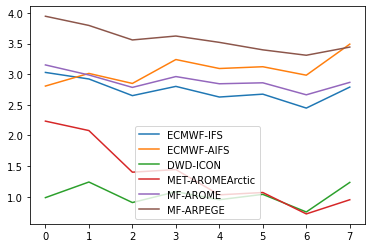

In [45]:
for i in range(6):
    plt.plot((np.transpose(np.nanmean(np.array(bias_all),axis=1)[i,:])),label=models[i])
    plt.legend()

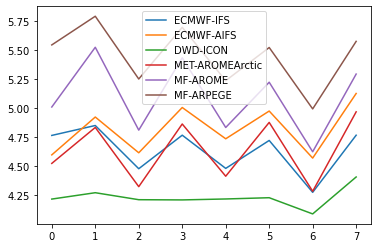

In [48]:
for i in range(6):
    plt.plot(np.sqrt(np.transpose(np.nanmean(np.array(rmse_all),axis=1)[i,:])),label=models[i])
    plt.legend()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cmocean

# Define the projection
plot_proj = ccrs.Orthographic(14, 25)

# Create a gridspec layout for precise subplot and colorbar control
fig = plt.figure(figsize=(18, 7))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)  # Adjust wspace for spacing

# Define shared colormap and limits for the first two plots
shared_cmap = 'viridis'  # Example colormap
shared_vmin = -30
shared_vmax = 5
# Plot 1
ax0 = fig.add_subplot(gs[0], projection=plot_proj)
ax0.coastlines(resolution='50m')
ax0.set_extent([-10, 30, 67, 88], crs=ccrs.PlateCarree())
contour1 = ax0.pcolormesh(
    m1.modis_lons, m1.modis_lats, m1.modisdata-273.15,
    transform=ccrs.PlateCarree(),
    cmap=shared_cmap,
    vmin=shared_vmin,
    vmax=shared_vmax
)

# Plot 2
ax1 = fig.add_subplot(gs[1], projection=plot_proj)
ax1.coastlines(resolution='50m')
ax1.set_extent([-10, 30, 67, 88], crs=ccrs.PlateCarree())
contour2 = ax1.pcolormesh(
    m1.modis_lons, m1.modis_lats, m1.MODprojdata-273.15,
    transform=ccrs.PlateCarree(),
    cmap=shared_cmap,
    vmin=shared_vmin,
    vmax=shared_vmax
)

# Plot 3 with its own colormap and limits
unique_cmap = cmocean.cm.tarn  # Example colormap
unique_vmin = -10  # Set according to your data range
unique_vmax = 10

ax2 = fig.add_subplot(gs[2], projection=plot_proj)
ax2.coastlines(resolution='50m')
ax2.set_extent([-10, 30, 67, 88], crs=ccrs.PlateCarree())
contour3 = ax2.pcolormesh(
    m1.modis_lons, m1.modis_lats, m1.MODprojdata - m1.modisdata,
    transform=ccrs.PlateCarree(),
    cmap=unique_cmap,
    vmin=unique_vmin,
    vmax=unique_vmax
)

# Shared colorbar for plots 1 & 2
cbar_ax1 = fig.add_subplot(gs[3])
cbar1 = fig.colorbar(contour1, cax=cbar_ax1)
cbar1.set_label('Shared Data Units')  # Adjust label as necessary

# Separate colorbar for plot 3
fig.subplots_adjust(right=0.95)  # Adjust for second colorbar
cbar2 = fig.colorbar(contour3, ax=ax2, orientation='vertical', pad=0.05, shrink=0.8)
cbar2.set_label('Difference Data Units')  # Adjust label as necessary

plt.tight_layout()
plt.show()
print ('RMSE ',np.sqrt(np.nanmean((m1.MODprojdata - m1.modisdata)**2)))
print ('ME   ',np.nanmean((m1.MODprojdata - m1.modisdata)))

In [ ]:
plt.plot(m1.MODprojdata-273.15,m1.modisdata-273.15,'.',color='k',alpha=0.5)

In [ ]:
plt.plot(m1.MODprojdata-273.15,m1.modisdata-273.15,'.',color='k',alpha=0.5)